[1]

In [2]:
!pip install ISLP --no-deps

  Using cached islp-0.4.1-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 4.0 MB/s  0:00:04m 5.0 MB/s eta 0:00:01


In [7]:
from ISLP import load_data
Wage = load_data('Wage')

In [8]:
Wage

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154
...,...,...,...,...,...,...,...,...,...,...,...
2995,2008,44,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.041393,154.685293
2996,2007,30,2. Married,1. White,2. HS Grad,2. Middle Atlantic,1. Industrial,2. >=Very Good,2. No,4.602060,99.689464
2997,2005,27,2. Married,2. Black,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.193125,66.229408
2998,2005,27,1. Never Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,4.477121,87.981033


In [14]:
import numpy as np
import pandas as pd

Wage = load_data('Wage')

Wage.dtypes

year             int64
age              int64
maritl        category
race          category
education     category
region        category
jobclass      category
health        category
health_ins    category
logwage        float64
wage           float64
dtype: object

In [13]:
num_cols = Wage.select_dtypes(include=[np.number]).columns
Wage_num = Wage[num_cols]

summary = pd.DataFrame({
    "min": Wage_num.min(),
    "max": Wage_num.max(),
    "median": Wage_num.median(),
    "mean": Wage_num.mean(),
    "std": Wage_num.std(),
    "unique": Wage_num.nunique()
})

summary

,min,max,median,mean,std,unique
year,2003.000000,2009.000000,2006.000000,2005.791000,2.026167,7
age,18.000000,80.000000,42.000000,42.414667,11.542406,61
logwage,3.000000,5.763128,4.653213,4.653905,0.351753,508
wage,20.085537,318.342430,104.921507,111.703608,41.728595,508


Overall these results make sense

[2]

In [15]:
from ISLP import load_data
Hitters = load_data('Hitters')

In [16]:
Hitters

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

H = Hitters.dropna(subset=["Salary"]).copy()

vars_list = ["AtBat","Hits","HmRun","Runs","RBI","Walks","Years"]

rows = []
for x in vars_list:
    X = sm.add_constant(H[[x]])     # adds intercept
    y = H["Salary"]
    fit = sm.OLS(y, X).fit()

    rows.append({
        "Predictor": x,
        "Intercept": fit.params["const"],
        "Slope": fit.params[x],
        "p_value": fit.pvalues[x],
        "t_stat": fit.tvalues[x],
        "R2": fit.rsquared,
        "RMSE": np.sqrt(fit.mse_resid),
    })

results = pd.DataFrame(rows).sort_values("p_value")
results


,Predictor,Intercept,Slope,p_value,t_stat,R2,RMSE
4,RBI,132.592455,7.833741,1.756983e-14,8.128496,0.202012,403.756449
5,Walks,156.861109,9.219831,4.013833e-14,8.002405,0.197018,405.017762
1,Hits,63.048819,4.385439,8.531228e-14,7.886318,0.192436,406.171836
3,Runs,129.929199,7.416108,1.179924e-12,7.473668,0.176281,410.214200
6,Years,260.234087,37.705118,1.462612e-11,7.064629,0.160526,414.118680
0,AtBat,47.938074,1.208960,3.065403e-11,6.941512,0.155844,415.271889
2,HmRun,330.593526,17.670946,1.125195e-08,5.899755,0.117668,424.558122


RBI's seem to be the best predictor of salary

[3]

In [23]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

from ISLP import load_data
Credit = load_data('Credit')

In [24]:
Credit

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331
...,...,...,...,...,...,...,...,...,...,...,...,...
395,396,12.096,4100,307,3,32,13,Male,No,Yes,Caucasian,560
396,397,13.364,3838,296,5,65,17,Male,No,No,African American,480
397,398,57.872,4171,321,5,67,12,Female,No,Yes,Caucasian,138
398,399,37.728,2525,192,1,44,13,Male,No,Yes,Caucasian,0


In [38]:
formula_multi = """
Rating ~ Income + Limit + Cards + Age + Education + Balance
         + C(Gender) + C(Student) + C(Married) + C(Ethnicity)
"""

multi_fit = smf.ols(formula_multi, data=Credit).fit()
multi_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Rating   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     8399.
Date:                Wed, 18 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:00:00   Log-Likelihood:                -1488.4
No. Observations:                 400   AIC:                             3001.
Df Residuals:                     388   BIC:                             3049.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    32.0084      4.136      7.739      0.000      23.877      40.140
C(Gender)[T.Female]           0.2204      1.020      0.216      0.829      -1.785       2.225
C(Student)[T.Yes]            -2.0068      2.805     -0.715      0.475      -7.522       3.508
C(Married)[T.Yes]             2.3823      1.058      2.251      0.025       0.301       4.463
C(Ethnicity)[T.Asian]        -2.0062      1.449     -1.384      0.167      -4.856       0.843
C(Ethnicity)[T.Caucasian]    -0.3096      1.255     -0.247      0.805      -2.777       2.158
Income                        0.1239      0.047      2.644      0.009       0.032       0.216
Limit                         0.0632      0.001     44.309      0.000       0.060       0.066
Cards                         4.5967      0.391     11.756      0.000       3.828       5.365
Age                           0.0126      0.030      0.415      0.679      -0.047       0.072
Education                    -0.2349      0.164     -1.434      0.152      -0.557       0.087
Balance                       0.0120      0.005      2.315      0.021       0.002       0.022
==============================================================================
Omnibus:                        6.295   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.043   Jarque-Bera (JB):                5.637
Skew:                           0.226   Prob(JB):                       0.0597
Kurtosis:                       2.633   Cond. No.                     4.65e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.65e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [26]:
multi_r2 = multi_fit.rsquared
multi_adj_r2 = multi_fit.rsquared_adj
multi_rmse = np.sqrt(multi_fit.mse_resid)

multi_r2, multi_adj_r2, multi_rmse


(np.float64(0.9958177633041255),
 np.float64(0.9956991947380054),
 np.float64(10.146890504549205))

In [27]:
predictors_num = ["Income", "Limit", "Cards", "Age", "Education", "Balance"]
predictors_cat = ["Gender", "Student", "Married", "Ethnicity"]

rows = []

for x in predictors_num:
    fit = smf.ols(f"Rating ~ {x}", data=Credit).fit()
    rows.append({
        "Predictor": x,
        "Type": "numeric",
        "R2": fit.rsquared,
        "RMSE": np.sqrt(fit.mse_resid),
        "p_value": fit.pvalues[x]  
    })

for x in predictors_cat:
    fit = smf.ols(f"Rating ~ C({x})", data=Credit).fit()
    
    p_overall = fit.f_pvalue
    rows.append({
        "Predictor": x,
        "Type": "categorical",
        "R2": fit.rsquared,
        "RMSE": np.sqrt(fit.mse_resid),
        "p_value": p_overall
    })

single_results = pd.DataFrame(rows).sort_values("RMSE")
single_results


,Predictor,Type,R2,RMSE,p_value
1,Limit,numeric,0.993769,12.228538,0.000000e+00
5,Balance,numeric,0.745848,78.099707,1.898899e-120
0,Income,numeric,0.626279,94.705895,4.362691e-87
3,Age,numeric,0.010643,154.091793,3.917457e-02
2,Cards,numeric,0.002834,154.698692,2.881441e-01
8,Married,categorical,0.001351,154.813744,4.635811e-01
4,Education,numeric,0.000908,154.848037,5.478647e-01
6,Gender,categorical,0.000079,154.912283,8.593990e-01
7,Student,categorical,0.000004,154.918079,9.677535e-01
9,Ethnicity,categorical,0.002030,154.955883,6.680979e-01


In [30]:
best_single = single_results.iloc[0]
best_single

Predictor        Limit
Type           numeric
R2            0.993769
RMSE         12.228538
p_value            0.0
Name: 1, dtype: object

In [31]:
best_single_rmse = best_single["RMSE"]
best_single_r2 = best_single["R2"]

delta_rmse = best_single_rmse - multi_rmse     # positive = multiple is better (smaller RMSE)
delta_r2 = multi_r2 - best_single_r2           # positive = multiple explains more variance

print("Best single predictor:", best_single["Predictor"])
print("Multiple RMSE:", multi_rmse)
print("Best single RMSE:", best_single_rmse)
print("RMSE improvement (single - multiple):", delta_rmse)

print("\nMultiple R2:", multi_r2)
print("Best single R2:", best_single_r2)
print("R2 improvement (multiple - single):", delta_r2)


Best single predictor: Limit
Multiple RMSE: 10.146890504549205
Best single RMSE: 12.228538411795146
RMSE improvement (single - multiple): 2.081647907245941

Multiple R2: 0.9958177633041255
Best single R2: 0.9937692100445441
R2 improvement (multiple - single): 0.0020485532595814204


[4]

In [50]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from ISLP import load_data
College = load_data("College")

College.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [53]:
College = College.copy()

College = College.rename(columns={
    "F.Undergrad": "F_Undergrad",
    "P.Undergrad": "P_Undergrad",
    "S.F.Ratio": "S_F_Ratio",
    "perc.alumni": "perc_alumni",
    "Grad.Rate": "Grad_Rate",
    "Room.Board": "Room_Board"
})

In [54]:
College["TotalCost"] = College["Outstate"] + College["Room_Board"] + College["Books"]

In [55]:
import statsmodels.formula.api as smf
import numpy as np

predictors = [
    "Apps","Accept","Enroll","Top10perc","Top25perc",
    "F_Undergrad","P_Undergrad",
    "Personal","PhD","Terminal",
    "S_F_Ratio","perc_alumni","Grad_Rate"
]

formula_base = "TotalCost ~ C(Private) + " + " + ".join(predictors)

base_fit = smf.ols(formula_base, data=College).fit()
base_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              TotalCost   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     123.3
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          7.30e-185
Time:                        10:08:58   Log-Likelihood:                -7232.5
No. Observations:                 777   AIC:                         1.449e+04
Df Residuals:                     762   BIC:                         1.456e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          4235.0232    978.402      4.329      0.000    2314.340    6155.706
C(Private)[T.Yes]  3946.8175    329.208     11.989      0.000    3300.556    4593.079
Apps                 -0.0218      0.091     -0.240      0.810      -0.200       0.156
Accept                0.8379      0.177      4.741      0.000       0.491       1.185
Enroll               -1.3123      0.485     -2.708      0.007      -2.264      -0.361
Top10perc            71.4018     14.268      5.004      0.000      43.392      99.412
Top25perc           -26.3884     11.449     -2.305      0.021     -48.864      -3.913
F_Undergrad          -0.1223      0.085     -1.445      0.149      -0.288       0.044
P_Undergrad           0.1984      0.083      2.400      0.017       0.036       0.361
Personal             -0.4157      0.160     -2.601      0.009      -0.730      -0.102
PhD                  15.9601     11.866      1.345      0.179      -7.334      39.254
Terminal             75.9142     12.769      5.945      0.000      50.848     100.980
S_F_Ratio          -201.8085     30.439     -6.630      0.000    -261.562    -142.055
perc_alumni          31.9792     10.318      3.099      0.002      11.723      52.235
Grad_Rate            44.1551      7.445      5.931      0.000      29.540      58.770
==============================================================================
Omnibus:                       19.695   Durbin-Watson:                   2.054
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.198
Skew:                          -0.107   Prob(JB):                     5.07e-09
Kurtosis:                       4.065   Cond. No.                     8.62e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.62e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [56]:
import pandas as pd
import numpy as np

base_metrics = {
    "Model": "Base",
    "R2": base_fit.rsquared,
    "Adj_R2": base_fit.rsquared_adj,
    "RMSE": float(np.sqrt(base_fit.mse_resid)),
    "AIC": base_fit.aic,
    "BIC": base_fit.bic
}
base_metrics


{'Model': 'Base',
 'R2': np.float64(0.6938134325407425),
 'Adj_R2': np.float64(0.6881879575480527),
 'RMSE': 2694.586786776455,
 'AIC': np.float64(14494.930028575649),
 'BIC': np.float64(14564.761633831164)}

In [57]:
num_cols = ["TotalCost"] + [
    "Apps","Accept","Enroll","Top10perc","Top25perc","F_Undergrad","P_Undergrad",
    "Personal","PhD","Terminal","S_F_Ratio","perc_alumni","Grad_Rate"
]

corr = College[num_cols].corr(numeric_only=True)["TotalCost"].sort_values(key=lambda s: s.abs(), ascending=False)
corr.head(10)

TotalCost      1.000000
Grad_Rate      0.572893
Top10perc      0.557304
S_F_Ratio     -0.546057
perc_alumni    0.532613
Top25perc      0.487294
Terminal       0.428674
PhD            0.395028
Personal      -0.288536
P_Undergrad   -0.222511
Name: TotalCost, dtype: float64

In [58]:
interaction_terms = [
    "C(Private):Top10perc",
    "Apps:Accept",
    "Top10perc:Top25perc"
]

formula_int = formula_base + " + " + " + ".join(interaction_terms)
int_fit = smf.ols(formula_int, data=College).fit()
int_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              TotalCost   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     115.8
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          2.34e-197
Time:                        10:11:27   Log-Likelihood:                -7195.4
No. Observations:                 777   AIC:                         1.443e+04
Df Residuals:                     759   BIC:                         1.451e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                    5817.1100    996.054      5.840      0.000    3861.762    7772.458
C(Private)[T.Yes]            3512.5249    430.754      8.154      0.000    2666.914    4358.136
Apps                            0.1526      0.100      1.521      0.129      -0.044       0.350
Accept                          1.4014      0.186      7.536      0.000       1.036       1.766
Enroll                         -2.2171      0.476     -4.660      0.000      -3.151      -1.283
Top10perc                     -41.1420     35.237     -1.168      0.243    -110.316      28.032
C(Private)[T.Yes]:Top10perc    39.7874     13.558      2.935      0.003      13.171      66.404
Top25perc                     -24.3818     11.071     -2.202      0.028     -46.114      -2.649
F_Undergrad                    -0.0928      0.082     -1.131      0.258      -0.254       0.068
P_Undergrad                     0.1814      0.079      2.286      0.023       0.026       0.337
Personal                       -0.4105      0.153     -2.686      0.007      -0.711      -0.111
PhD                            12.3674     11.512      1.074      0.283     -10.232      34.966
Terminal                       67.2370     12.250      5.489      0.000      43.190      91.284
S_F_Ratio                    -191.2476     29.131     -6.565      0.000    -248.434    -134.061
perc_alumni                    38.8639     10.000      3.886      0.000      19.233      58.494
Grad_Rate                      35.6403      7.221      4.936      0.000      21.465      49.816
Apps:Accept                 -2.471e-05   3.51e-06     -7.033      0.000   -3.16e-05   -1.78e-05
Top10perc:Top25perc             0.7536      0.338      2.226      0.026       0.089       1.418
==============================================================================
Omnibus:                       14.031   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               24.678
Skew:                           0.047   Prob(JB):                     4.38e-06
Kurtosis:                       3.868   Cond. No.                     6.44e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.44e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [59]:
int_metrics = {
    "Model": "With interactions",
    "R2": int_fit.rsquared,
    "Adj_R2": int_fit.rsquared_adj,
    "RMSE": float(np.sqrt(int_fit.mse_resid)),
    "AIC": int_fit.aic,
    "BIC": int_fit.bic
}

pd.DataFrame([base_metrics, int_metrics]).sort_values("RMSE")

,Model,R2,Adj_R2,RMSE,AIC,BIC
1,With interactions,0.721695,0.715461,2574.047577,14426.745700,14510.543626
0,Base,0.693813,0.688188,2694.586787,14494.930029,14564.761634


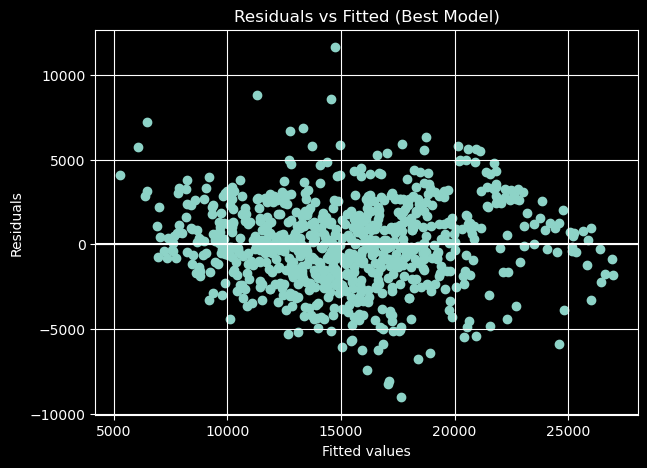

In [60]:
import matplotlib.pyplot as plt

best_fit = int_fit if int_metrics["RMSE"] < base_metrics["RMSE"] else base_fit

plt.figure(figsize=(7,5))
plt.scatter(best_fit.fittedvalues, best_fit.resid)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Best Model)")
plt.grid(True)
plt.show()

The interaction model performs better because it makes smaller prediction mistakes on average and explains the variation.